# Отчёт по эксперименту с применением MLP

## Проделанная работа

В рамках экспериментов была выполнена следующая работа:

1. **RandomizedSearch для Logistic Regression** (500 итераций, 5 фолдов) — подбор параметров: C, penalty, l1_ratio, tol, max_iter, class_weight, fit_intercept
2. **RandomizedSearch для Decision Tree** (500 итераций, 5 фолдов) — подбор: max_depth, min_samples_split, min_samples_leaf, criterion, max_features, ccp_alpha и др.
3. **RandomizedSearch для Random Forest** (30 итераций, 3 фолда) — подбор: n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features, criterion, bootstrap
4. **Ручная настройка Random Forest** на основе лучших параметров

## Результаты моделей (валидационная выборка)

| Модель | Accuracy | F1 | Precision | Recall | ROC-AUC |
|--------|----------|-----|-----------|--------|---------|
| **Logistic Regression (оптимизир.)** | 0.674 | 0.331 | 0.217 | 0.693 | 0.749 |
| **Decision Tree (оптимизир.)** | 0.685 | 0.319 | 0.213 | 0.635 | 0.726 |
| **Random Forest (оптимизир.)** | 0.814 | 0.365 | 0.303 | 0.459 | 0.750 |
| **Random Forest (улучшенный)** | 0.814 | 0.364 | 0.302 | 0.458 | 0.752 |

## Сравнение с бейзлайнами

| Модель | Бейзлайн F1 | Оптимизир. F1 | Изменение |
|--------|-------------|---------------|-----------|
| **Logistic Regression** | 0.331 | 0.331 | **0.000** |
| **Decision Tree** | 0.289 | 0.319 | **+0.030** |
| **Random Forest** | 0.353 | 0.365 | **+0.012** |

## Ключевые выводы

**Ощутимого прироста качества не получено**

| Модель | Проблема |
|--------|----------|
| **Logistic Regression** | Низкий Precision (~22%) при высоком Recall (~69%) — модель слишком агрессивно предсказывает дефолты |
| **Decision Tree** | Precision ещё ниже (~19-21%), Recall ~63% — дерево явно переобучено даже с ограничениями |
| **Random Forest** | Лучший Precision (~30%), но низкий Recall (~46%) — модель слишком консервативна |

## Сохранённые артефакты

| Тип | Путь |
|-----|------|
| Метрики моделей | `../artifacts/Experiments/runsExp.csv` |
| Матрицы ошибок | `../artifacts/Experiments/figures` |
| ROC-кривые | `../artifacts/Experiments/figures` |
| PR-кривые | `../artifacts/Experiments/figures` |
| Конфиги моделей | `../artifacts/Experiments/configs/experiments_config.json` |



In [63]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import copy
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTETomek
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print(f"device: {device}")

torch: 2.1.2+cu118
cuda: 11.8
device: cuda


In [60]:
def f_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    preds = preds.view(-1)   
    y_true = y_true.view(-1)
    tp = ((preds == 1) & (y_true == 1)).sum().float()
    fp = ((preds == 1) & (y_true == 0)).sum().float()
    fn = ((preds == 0) & (y_true == 1)).sum().float()
    
    # Считаем precision и recall
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    # Считаем F1
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    return f1.item()

def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_f": [...],  "val_f": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig("../artifacts/ExperimentMLP/figures/loss_hist.png")
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_f"], label="train_f")
    plt.plot(epochs, history["val_f"], label="val_f")
    plt.xlabel("epoch")
    plt.ylabel("Fscore")
    plt.title((title + " (Fscore)") if title else "Fscore")
    plt.legend()
    plt.grid(True)
    plt.savefig("../artifacts/ExperimentMLP/figures/f_hist.png")
    plt.show()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_f = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logists = model(x)
        loss = criterion(logists, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_f += f_from_logits(logists, y)
        n_batches += 1

    return total_loss / n_batches, total_f / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device): 
    model.eval()
    total_loss = 0.0
    total_f = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logists = model(x)
        loss = criterion(logists, y)

        total_loss += loss.item()
        total_f += f_from_logits(logists, y)
        n_batches += 1

    return total_loss / n_batches, total_f / n_batches

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_f": [],  "val_f": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_f = evaluate(model, val_loader, criterion, device)

        history["train_f"].append(tr_f)
        history["train_loss"].append(tr_loss)
        history["val_f"].append(val_f)
        history["val_loss"].append(val_loss)

        if verbose:
            print(
                    f"epoch {epoch:02d}/{epochs} | "
                    f"train loss={tr_loss:.4f}, f={tr_f:.4f} | "
                    f"val loss={val_loss:.4f}, f={val_f:.4f}"
                )
        
        if early_stopping is not None:
            if early_stopping.step(val_f, model):
                if verbose:
                    print(f"Остановка на эпохе {epoch};\nСворачиваем всю порнографиб, лучший результат: val_f={early_stopping.best_score}")
                early_stopping.restore_best(model)
                break

    return history

class DataFrameDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, target_column, feature_columns=None, transform=None):
        self.dataframe = dataframe
        self.target_column = target_column
        
        if feature_columns is None:
            self.feature_columns = [col for col in dataframe.columns if col != target_column]
        else:
            self.feature_columns = feature_columns
        
        self.transform = transform
        self.X = dataframe[self.feature_columns].values.astype(np.float32)
        self.y = dataframe[target_column].values.astype(np.int64)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        
        # Применяем трансформации (например, нормализацию)
        if self.transform:
            x = self.transform(x)
        
        # Преобразуем в тензоры
        x = torch.from_numpy(x)
        y = torch.tensor(y, dtype=torch.long)
        
        return x, y
    
    def forFit(self):
        return self.X
    
    def setTrans(self, trans):
        self.transform = trans
    
class StandardScalerTransform:
    def __init__(self, scaler=None):
        self.scaler = scaler or StandardScaler()
    
    def fit(self, X):  # X - numpy array
        self.scaler.fit(X)
        return self
    
    def __call__(self, x):  # x - numpy array
        return self.scaler.transform(x.reshape(1, -1)).flatten()

In [55]:
df = pd.read_csv("../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv")

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["Default"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["Default"])

scaler = StandardScaler()
scaler.fit(train_df.drop("Default", axis=1).values.astype(np.float32))

transformer = StandardScalerTransform(scaler)

train_ds = DataFrameDataset(train_df, "Default", transform=transformer)
val_ds = DataFrameDataset(val_df, "Default", transform=transformer)
test_ds = DataFrameDataset(test_df, "Default", transform=transformer)

print(f"train size: {len(train_ds)}")
print(f"train size: {len(val_ds)}")
print(f"test size: {len(test_ds)}")

train size: 178742
train size: 38302
test size: 38303


In [56]:
train_loader = DataLoader(train_ds, batch_size=512, num_workers=0, shuffle=True, pin_memory="False")
val_loader = DataLoader(val_ds, batch_size=512, num_workers=0, shuffle=False, pin_memory="False")
test_loader = DataLoader(test_ds, batch_size=512, num_workers=0, shuffle=False, pin_memory="False")

x_batch, y_batch = next(iter(train_loader))
print(f"x_batch: {x_batch.shape}, {x_batch.dtype}")
print(f"y_batch: {y_batch.shape}, {y_batch.dtype}")

x_batch: torch.Size([512, 31]), torch.float32
y_batch: torch.Size([512]), torch.int64


In [57]:
class MLP(nn.Module):
    def __init__(
            self, 
            input_dim=31,
            hidden_dims=(1024, 512, 1024, 512, 256, 512, 256, 128, 256, 128, 64, 128, 64, 32, 64, 32),
            num_classes=2,
            activation="relu",
            dropout_p=0.25,
            use_batchnorm=True):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


epoch 01/30 | train loss=0.6536, f=0.2772 | val loss=0.6216, f=0.3424
epoch 02/30 | train loss=0.6106, f=0.3228 | val loss=0.5949, f=0.3456
epoch 03/30 | train loss=0.6020, f=0.3310 | val loss=0.5949, f=0.3472
epoch 04/30 | train loss=0.5996, f=0.3352 | val loss=0.5905, f=0.3393
epoch 05/30 | train loss=0.5968, f=0.3342 | val loss=0.5903, f=0.3398
epoch 06/30 | train loss=0.5971, f=0.3324 | val loss=0.5904, f=0.3558
epoch 07/30 | train loss=0.5959, f=0.3318 | val loss=0.5897, f=0.3306
epoch 08/30 | train loss=0.5943, f=0.3376 | val loss=0.5890, f=0.3492
epoch 09/30 | train loss=0.5936, f=0.3360 | val loss=0.5896, f=0.3455
epoch 10/30 | train loss=0.5926, f=0.3374 | val loss=0.5907, f=0.3399
epoch 11/30 | train loss=0.5926, f=0.3378 | val loss=0.5889, f=0.3432
epoch 12/30 | train loss=0.5922, f=0.3415 | val loss=0.5878, f=0.3454
epoch 13/30 | train loss=0.5901, f=0.3398 | val loss=0.5877, f=0.3500
epoch 14/30 | train loss=0.5901, f=0.3412 | val loss=0.5891, f=0.3297
epoch 15/30 | train 

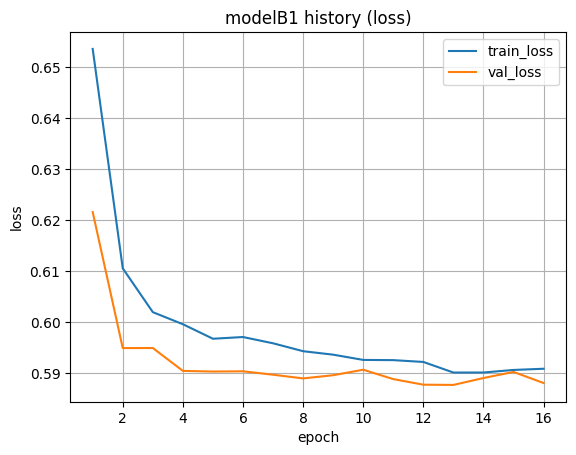

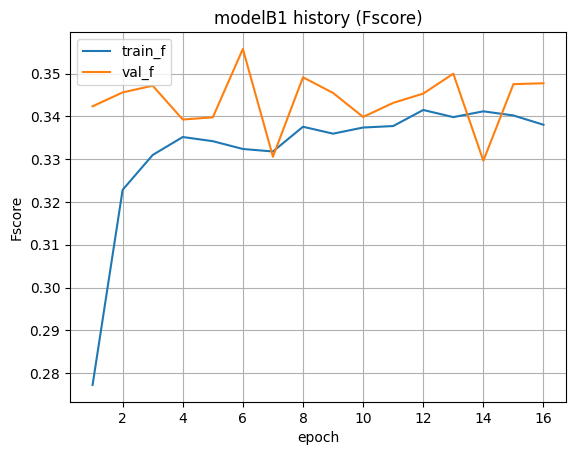

In [61]:
modelB1 = MLP().to(device)

classes = np.unique(train_df["Default"])
class_weights = compute_class_weight('balanced', classes=classes, y=train_df["Default"])
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(modelB1.parameters(), lr=1e-3)

history_B1 = fit(modelB1, train_loader, val_loader, optimizer, criterion, device, epochs=30, early_stopping=EarlyStopping(10))

plot_history(history_B1, "modelB1 history")

In [64]:
def compute_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
    }
    
    if y_proba is not None:
        try:
            metrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            metrics["roc_auc"] = None
    else:
        metrics["roc_auc"] = None
    
    return metrics


def evaluate_on_test_mlp(model, test_loader, device, label="MLP"):
    model.eval()
    all_preds = []
    all_probas = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            
            # Предсказания классов
            preds = torch.argmax(logits, dim=1)
            
            # Вероятности (для ROC-AUC)
            probs = torch.softmax(logits, dim=1)[:, 1]
            
            all_preds.extend(preds.cpu().numpy())
            all_probas.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    metrics = compute_metrics(all_labels, all_preds, all_probas)
    metrics["model"] = label
    
    return metrics

runsMLP = [evaluate_on_test_mlp(modelB1, val_loader, device)]
print(runsMLP)

[{'accuracy': 0.7521017179259568, 'f1': 0.3568380410485674, 'precision': 0.2553562772661173, 'recall': 0.5921762589928058, 'roc_auc': 0.7543502671278233, 'model': 'MLP'}]


In [66]:
def save_metrics_to_csv(metrics_list, filepath):
    # Создаём DataFrame из списка
    df_metrics = pd.DataFrame(metrics_list)
    
    # Сортируем по ROC-AUC (опционально)
    df_metrics = df_metrics.sort_values('f1', ascending=False)
        
    # Сохраняем в CSV
    df_metrics.to_csv(filepath, index=False)
    print("ГОТОВО!")

save_metrics_to_csv(runsMLP, "../artifacts/ExperimentMLP/runsMLP.csv")

ГОТОВО!


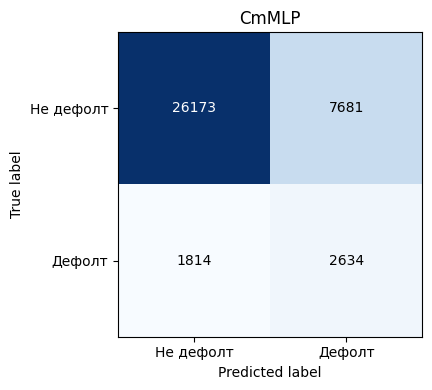

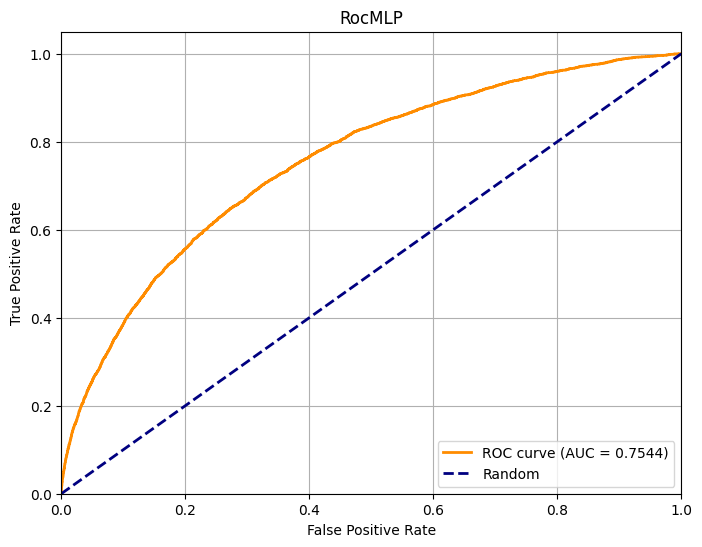

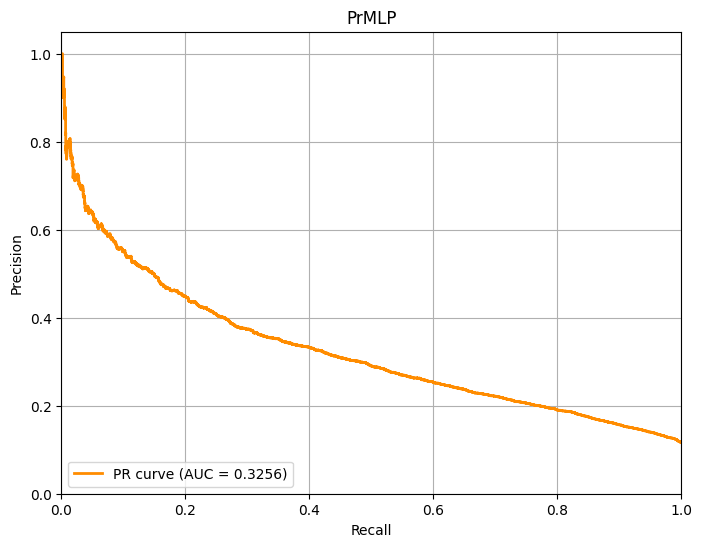

In [65]:
#рисует матрицу ошибок
def plot_confusion(model, dataloader, device, title: str):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ['Не дефолт', 'Дефолт'])
    plt.yticks([0, 1], ['Не дефолт', 'Дефолт'])
    
    # Добавляем значения в ячейки
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    pth = f"../artifacts/ExperimentMLP/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

#рисует roc кривую
def plot_roc(model, dataloader, device, title: str):
    model.eval()
    all_probas = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]  # вероятность класса 1 (дефолт)
            all_probas.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Вычисляем ROC
    fpr, tpr, _ = roc_curve(all_labels, all_probas)
    roc_auc = auc(fpr, tpr)
    
    # Рисуем
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    
    pth = f"../artifacts/ExperimentMLP/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

def plot_prd(model, dataloader, device, title: str):
    model.eval()
    all_probas = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probas.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    # Вычисляем Precision-Recall
    precision, recall, _ = precision_recall_curve(all_labels, all_probas)
    pr_auc = auc(recall, precision)
    
    # Рисуем
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(loc="lower left")
    plt.grid(True)
    
    pth = f"../artifacts/ExperimentMLP/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

plot_confusion(modelB1, val_loader, device, "CmMLP")

plot_roc(modelB1, val_loader, device, "RocMLP")

plot_prd(modelB1, val_loader, device, "PrMLP")

In [67]:
# Основная конфигурация эксперимента
EXPERIMENT_MLP_CONFIG = {
    "data_path": "../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv",
    "target_column": "Default",
    "random_state": 42,
    "test_size": 0.3,
    "val_size": 0.5,  # 50% от test_size (0.3 * 0.5 = 0.15 от общего датасета)
    "stratify": True,
    "device": "cuda",
    "description": "MLP model for binary classification with class imbalance handling"
}

# Конфигурация предобработки данных
PREPROCESSING_CONFIG = {
    "scaler": {
        "name": "StandardScaler",
        "fit_on": "train",
        "transform_all": True
    },
    "data_loader": {
        "batch_size": 512,
        "num_workers": 0,
        "pin_memory": False,
        "shuffle_train": True,
        "shuffle_val_test": False
    }
}

# Конфигурация MLP модели
MLP_CONFIG = {
    "model_name": "MLP_MultiLayerPerceptron",
    "is_pytorch_model": True,
    "architecture": {
        "input_dim": 31,  # Количество признаков после one-hot encoding
        "hidden_dims": [
            1024, 512, 1024, 512, 256, 512, 256, 128, 
            256, 128, 64, 128, 64, 32, 64, 32
        ],
        "num_classes": 2,
        "activation": "relu",
        "dropout_p": 0.25,
        "use_batchnorm": True
    },
    "optimizer": {
        "name": "Adam",
        "learning_rate": 0.001,
        "params": {
            "betas": [0.9, 0.999],
            "eps": 1e-8,
            "weight_decay": 0.0,
            "amsgrad": False
        }
    },
    "criterion": {
        "name": "CrossEntropyLoss",
        "class_weight": "balanced",
        "computed_from": "y_train"
    },
    "training": {
        "max_epochs": 30,
        "early_stopping_patience": 10,
        "early_stopping_min_delta": 0.0,
        "gradient_clip_norm": 1.0,
        "class_weights_calculation": "compute_class_weight('balanced')"
    }
}

# Конфигурация модели после обучения (best model)
MLP_BEST_CONFIG = {
    "model_name": "MLP_BestModel",
    "is_pytorch_model": True,
    "architecture": {
        "input_dim": 31,
        "hidden_dims": [
            1024, 512, 1024, 512, 256, 512, 256, 128, 
            256, 128, 64, 128, 64, 32, 64, 32
        ],
        "num_classes": 2,
        "activation": "relu",
        "dropout_p": 0.25,
        "use_batchnorm": True
    },
    "training_info": {
        "stopped_epoch": 16,
        "best_val_f1": 0.3557939898967743,
        "total_epochs_trained": 16
    }
}

# Параметры для возможной оптимизации (если бы использовался Grid/Random Search)
MLP_RANDOM_SEARCH_PARAMS = {
    "enabled": False,  # В текущем эксперименте Random Search не использовался
    "n_iter": None,
    "cv": None,
    "scoring": "f1",
    "param_distributions": {
        "learning_rate": ["loguniform(1e-4, 1e-2)"],
        "dropout_p": ["uniform(0.1, 0.5)"],
        "hidden_dims_config": ["predefined"],
        "batch_size": [256, 512, 1024],
        "optimizer": ["Adam", "AdamW", "SGD"],
        "activation": ["relu", "gelu", "tanh"]
    }
}

# Сводный словарь со всеми конфигурациями MLP эксперимента
ALL_MLP_EXPERIMENTS_CONFIG = {
    "experiment": EXPERIMENT_MLP_CONFIG,
    "preprocessing": PREPROCESSING_CONFIG,
    "random_search_params": MLP_RANDOM_SEARCH_PARAMS,
    "models": {
        "mlp_trained": MLP_CONFIG,
        "mlp_best": MLP_BEST_CONFIG
    },
    "evaluation_metrics": [
        "accuracy",
        "f1_score",
        "precision",
        "recall",
        "roc_auc"
    ],
    "outputs": {
        "metrics_csv": "../artifacts/ExperimentMLP/runsMLP.csv",
        "figures_directory": "../artifacts/ExperimentMLP/figures",
        "figures": [
            {
                "name": "loss_hist.png",
                "type": "training_history",
                "title": "modelB1 history (loss)"
            },
            {
                "name": "f_hist.png",
                "type": "training_history",
                "title": "modelB1 history (Fscore)"
            },
            {
                "name": "CmMLP.png",
                "type": "confusion_matrix",
                "title": "CmMLP"
            },
            {
                "name": "RocMLP.png",
                "type": "roc_curve",
                "title": "RocMLP"
            },
            {
                "name": "PrMLP.png",
                "type": "pr_curve",
                "title": "PrMLP"
            }
        ]
    },
    "model_hyperparameters_summary": {
        "total_parameters": "~1.5M (estimated)",
        "hidden_layers_count": 16,
        "dropout_p": 0.25,
        "batch_norm": True,
        "activation_function": "ReLU"
    },
    "training_notes": {
        "class_imbalance_handling": "class_weight='balanced' for CrossEntropyLoss",
        "early_stopping": "Stopped at epoch 16, best val_f1=0.3558",
        "device_used": "cuda",
        "pytorch_version": "2.1.2+cu118",
        "cuda_version": "11.8",
        "gradient_clipping": "enabled (max_norm=1.0)"
    }
}

# Сохраняем общий конфиг
with open("../configs/experimentMLP_config.json", "w") as f:
    json.dump(ALL_MLP_EXPERIMENTS_CONFIG, f, indent=4)